# Benchmark: photo_c3_medlyn_farquhar vs photo_c3_medlyn_farquhar_fast

Tests correctness and timing of the optimized photosynthesis function.

In [1]:
import numpy as np
import timeit
import matplotlib.pyplot as plt

from pyAPES.leaf.photo import (
    photo_c3_medlyn_farquhar,
    photo_c3_medlyn_farquhar_fast,
    photo_temperature_response,
    photo_temperature_response_fast,
)
%matplotlib widget

In [2]:
# --- Photosynthesis parameters (pine, Tarvainen et al. 2018)
photop = {
    'Vcmax': 94.0,
    'Jmax': 143.0,
    'Rd': 1.3,
    'alpha': 0.2,
    'theta': 0.7,
    'g1': 2.3,
    'g0': 1.0e-3,
    'beta': 0.95,
    'tresp': {
        'Vcmax': [78.3, 200.0, 650.1],
        'Jmax': [56.0, 200.0, 647.9],
        'Rd': [33.0]
    }
}

P = 101300.0

## 1. Correctness check

Results must be numerically identical.

In [3]:
rng = np.random.default_rng(42)
N = 50

Qp   = rng.uniform(10, 1800, N)
T    = rng.uniform(2, 38, N)
VPD  = rng.uniform(0.2, 3.0, N) / P * 1e3  # mol/mol
ca   = np.full(N, 400.0)
gb_c = np.full(N, 0.5)
gb_v = np.full(N, 0.8)

orig = photo_c3_medlyn_farquhar(photop, Qp, T, VPD, ca, gb_c, gb_v, P=P)
fast = photo_c3_medlyn_farquhar_fast(photop, Qp, T, VPD, ca, gb_c, gb_v, P=P)

labels = ['An', 'Rd', 'fe', 'gs_opt', 'ci', 'cs']
print(f"{'Variable':<10} {'Max abs diff':>15} {'Max rel diff':>15}")
print("-" * 42)
all_ok = True
for name, o, f in zip(labels, orig, fast):
    abs_diff = np.max(np.abs(o - f))
    rel_diff = np.max(np.abs(o - f) / (np.abs(o) + 1e-12))
    ok = abs_diff < 1e-10
    all_ok = all_ok and ok
    print(f"{name:<10} {abs_diff:>15.2e} {rel_diff:>15.2e}  {'OK' if ok else 'MISMATCH'}")

print()
print('All results match:', all_ok)

Variable      Max abs diff    Max rel diff
------------------------------------------
An                1.07e-14        2.13e-15  OK
Rd                1.67e-16        3.74e-16  OK
fe                1.73e-18        1.81e-15  OK
gs_opt            1.32e-16        2.18e-15  OK
ci                8.53e-14        3.60e-16  OK
cs                5.68e-14        1.52e-16  OK

All results match: True


## 2. Timing — varying array size

Typical call in the model uses an array the size of the canopy layer count (~20–100 elements).

In [4]:
REPEAT = 5
NUMBER = 2000  # calls per repeat

sizes = [10, 20, 50, 100, 200]
times_orig = []
times_fast = []

for N in sizes:
    rng = np.random.default_rng(0)
    Qp   = rng.uniform(10, 1800, N)
    T    = rng.uniform(2, 38, N)
    VPD  = rng.uniform(0.2, 3.0, N) / P * 1e3
    ca   = np.full(N, 400.0)
    gb_c = np.full(N, 0.5)
    gb_v = np.full(N, 0.8)

    t_orig = min(timeit.repeat(
        lambda: photo_c3_medlyn_farquhar(photop, Qp, T, VPD, ca, gb_c, gb_v, P=P),
        repeat=REPEAT, number=NUMBER
    ))
    t_fast = min(timeit.repeat(
        lambda: photo_c3_medlyn_farquhar_fast(photop, Qp, T, VPD, ca, gb_c, gb_v, P=P),
        repeat=REPEAT, number=NUMBER
    ))

    times_orig.append(t_orig / NUMBER * 1e6)  # microseconds per call
    times_fast.append(t_fast / NUMBER * 1e6)
    speedup = t_orig / t_fast
    print(f"N={N:4d}  orig={times_orig[-1]:7.1f} us  fast={times_fast[-1]:7.1f} us  speedup={speedup:.2f}x")

N=  10  orig=   86.8 us  fast=   74.7 us  speedup=1.16x
N=  20  orig=  151.5 us  fast=  122.9 us  speedup=1.23x
N=  50  orig=  135.9 us  fast=  107.2 us  speedup=1.27x
N= 100  orig=   99.2 us  fast=   74.3 us  speedup=1.33x
N= 200  orig=  125.0 us  fast=   83.8 us  speedup=1.49x


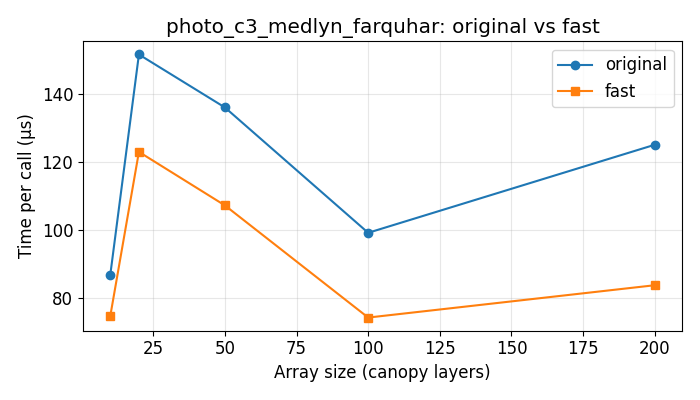

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, times_orig, 'o-', label='original')
ax.plot(sizes, times_fast, 's-', label='fast')
ax.set_xlabel('Array size (canopy layers)')
ax.set_ylabel('Time per call (µs)')
ax.set_title('photo_c3_medlyn_farquhar: original vs fast')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


## 3. Iteration count distribution

How many iterations does the solver typically take? Fewer iterations = more room for speedup.

Iterations: min=5  median=8  max=49  mean=14.7


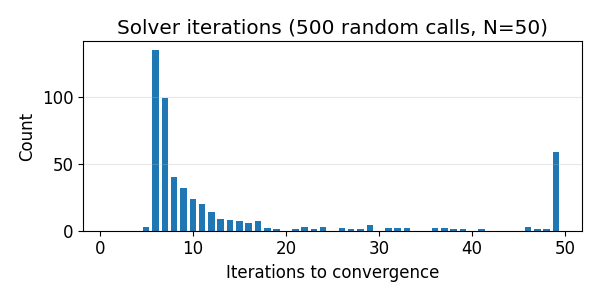

In [6]:
def photo_c3_medlyn_farquhar_count_iters(photop, Qp, T, VPD, ca, gb_c, gb_v, P=101300.0):
    """Copy of the original with iteration counter returned."""
    from pyAPES.utils.constants import DEG_TO_KELVIN, EPS, GAS_CONSTANT, O2_IN_AIR, H2O_CO2_RATIO, TN_GAS_CONSTANT, TN
    from pyAPES.leaf.photo import photo_temperature_response

    Tk = T + DEG_TO_KELVIN
    VPD = np.maximum(EPS, 1e-3 * VPD * P)
    Vcmax = photop['Vcmax']; Jmax = photop['Jmax']; Rd = photop['Rd']
    alpha = photop['alpha']; theta = photop['theta']
    g1 = photop['g1']; g0 = photop['g0']; beta = photop['beta']

    TN_GAS_CONSTANT_Tk = TN * GAS_CONSTANT * Tk
    Tk_minus_TN = Tk - TN
    Tau_c = 42.75 * np.exp(37830*(Tk_minus_TN) / (TN_GAS_CONSTANT_Tk))
    Kc = 404.9 * np.exp(79430.0*(Tk_minus_TN) / (TN_GAS_CONSTANT_Tk))
    Ko = 2.784e5 * np.exp(36380.0*(Tk_minus_TN) / (TN_GAS_CONSTANT_Tk))

    if 'tresp' in photop:
        tresp = photop['tresp']
        Vcmax, Jmax, Rd, Tau_c = photo_temperature_response(
            Vcmax, Jmax, Rd, tresp['Vcmax'], tresp['Jmax'], tresp['Rd'], Tk)

    Km = Kc*(1.0 + O2_IN_AIR / Ko)
    J = (Jmax + alpha*Qp - ((Jmax + alpha*Qp)**2.0 - (4*theta*Jmax*alpha*Qp))**0.5) / (2*theta)

    err = 9999.0; cnt = 1
    cs = ca; ci = 0.8*ca
    while err > 0.01 and cnt < 50:
        Av = Vcmax * (ci - Tau_c) / (ci + Km)
        Aj = J/4.0 * (ci - Tau_c) / (ci + 2.0*Tau_c)
        x = Av + Aj; y = Av * Aj
        An = (x - (x**2.0 - 4.0*beta*y)**0.5) / (2.0*beta) - Rd
        An1 = np.maximum(An, 0.0)
        gs_opt = g0 + (1.0 + g1 / (VPD**0.5)) * An1 / cs
        gs_opt[gs_opt < g0] = g0
        cs = np.maximum(ca - An1 / gb_c, 0.5*ca)
        ci0 = ci
        ci = np.maximum(cs - An1 / gs_opt, 0.1*ca)
        err = max((ci0 - ci)*(ci0-ci))
        cnt += 1
    return cnt - 1

# Sample many random conditions
N_samples = 500
N_layers = 50
rng = np.random.default_rng(7)
iter_counts = []
for _ in range(N_samples):
    Qp   = rng.uniform(0, 1800, N_layers)
    T    = rng.uniform(-5, 40, N_layers)
    VPD  = rng.uniform(0.05, 4.0, N_layers) / P * 1e3
    ca   = np.full(N_layers, rng.uniform(380, 420))
    gb_c = np.full(N_layers, rng.uniform(0.1, 1.0))
    gb_v = np.full(N_layers, rng.uniform(0.2, 1.5))
    iter_counts.append(photo_c3_medlyn_farquhar_count_iters(photop, Qp, T, VPD, ca, gb_c, gb_v, P=P))

print(f"Iterations: min={min(iter_counts)}  median={np.median(iter_counts):.0f}  max={max(iter_counts)}  mean={np.mean(iter_counts):.1f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(iter_counts, bins=range(1, max(iter_counts)+2), align='left', rwidth=0.7)
ax.set_xlabel('Iterations to convergence')
ax.set_ylabel('Count')
ax.set_title(f'Solver iterations ({N_samples} random calls, N={N_layers})')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

## 4. photo_temperature_response: correctness and timing

Optimizations: precompute `T_ratio = T_minus_TN / TN_GAS_CONSTANT_T` (used in 4 exp numerators — saves 3 array divisions) and `inv_T_GAS_CONSTANT` (used in 2 DENOM expressions — saves 1 array division).

N=  10  orig=   8.11 us  fast=   8.05 us  speedup=1.01x
N=  20  orig=   8.19 us  fast=   8.08 us  speedup=1.01x
N=  50  orig=   8.59 us  fast=   8.38 us  speedup=1.03x
N= 100  orig=   9.51 us  fast=   9.42 us  speedup=1.01x
N= 200  orig=  11.44 us  fast=  11.15 us  speedup=1.03x


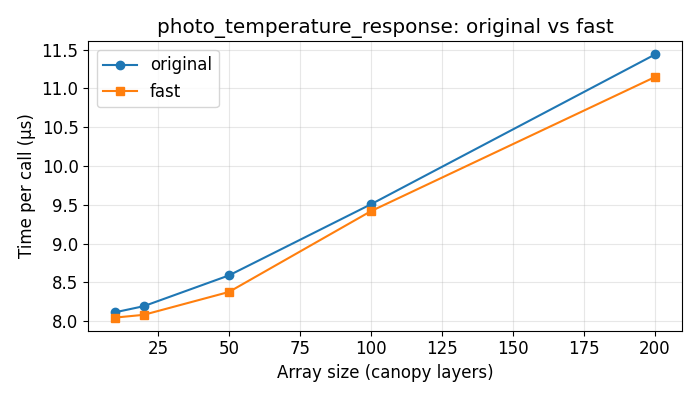

In [8]:
# --- Timing: photo_temperature_response vs photo_temperature_response_fast
REPEAT = 5
NUMBER = 5000

sizes_tr = [10, 20, 50, 100, 200]
times_tr_orig = []
times_tr_fast = []

Vcmax0 = photop['Vcmax']
Jmax0 = photop['Jmax']
Rd0 = photop['Rd']
Vcmax_T = photop['tresp']['Vcmax']
Jmax_T = photop['tresp']['Jmax']
Rd_T = photop['tresp']['Rd']

for N in sizes_tr:
    rng = np.random.default_rng(1)
    Tk = rng.uniform(275, 313, N)

    t_orig = min(timeit.repeat(
        lambda: photo_temperature_response(Vcmax0, Jmax0, Rd0, Vcmax_T, Jmax_T, Rd_T, Tk),
        repeat=REPEAT, number=NUMBER
    ))
    t_fast = min(timeit.repeat(
        lambda: photo_temperature_response_fast(Vcmax0, Jmax0, Rd0, Vcmax_T, Jmax_T, Rd_T, Tk),
        repeat=REPEAT, number=NUMBER
    ))

    times_tr_orig.append(t_orig / NUMBER * 1e6)
    times_tr_fast.append(t_fast / NUMBER * 1e6)
    speedup = t_orig / t_fast
    print(f"N={N:4d}  orig={times_tr_orig[-1]:7.2f} us  fast={times_tr_fast[-1]:7.2f} us  speedup={speedup:.2f}x")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes_tr, times_tr_orig, 'o-', label='original')
ax.plot(sizes_tr, times_tr_fast, 's-', label='fast')
ax.set_xlabel('Array size (canopy layers)')
ax.set_ylabel('Time per call (µs)')
ax.set_title('photo_temperature_response: original vs fast')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [9]:
# --- Correctness check: photo_temperature_response vs photo_temperature_response_fast
rng = np.random.default_rng(99)
N = 50
Tk = rng.uniform(275, 313, N)  # 2..40 degC in Kelvin

Vcmax0 = 94.0
Jmax0  = 143.0
Rd0    = 1.3
Vcmax_T = [78.3, 200.0, 650.1]
Jmax_T  = [56.0, 200.0, 647.9]
Rd_T    = [33.0]

o = photo_temperature_response(Vcmax0, Jmax0, Rd0, Vcmax_T, Jmax_T, Rd_T, Tk)
f = photo_temperature_response_fast(Vcmax0, Jmax0, Rd0, Vcmax_T, Jmax_T, Rd_T, Tk)

labels_tr = ['Vcmax', 'Jmax', 'Rd', 'Gamma_star']
print(f"{'Variable':<12} {'Max abs diff':>15} {'Max rel diff':>15}")
print("-" * 44)
all_ok = True
for name, ov, fv in zip(labels_tr, o, f):
    abs_diff = np.max(np.abs(ov - fv))
    rel_diff = np.max(np.abs(ov - fv) / (np.abs(ov) + 1e-12))
    ok = abs_diff < 1e-10
    all_ok = all_ok and ok
    print(f"{name:<12} {abs_diff:>15.2e} {rel_diff:>15.2e}  {'OK' if ok else 'MISMATCH'}")

print()
print('All results match:', all_ok)

Variable        Max abs diff    Max rel diff
--------------------------------------------
Vcmax               4.26e-14        5.41e-16  OK
Jmax                1.42e-14        2.51e-16  OK
Rd                  4.44e-16        3.26e-16  OK
Gamma_star          7.11e-15        3.85e-16  OK

All results match: True
